# Notebook 01 -- Model Demonstration (M1)

This notebook is the M1 deliverable from
[`../../cstr_sbi_execution_plan.md`](../../cstr_sbi_execution_plan.md):
the closed-loop CSTR ODE with a PI controller, anti-windup, and the two
multiplicative degradation factors (alpha for catalyst decay, beta for
jacket fouling), all running on the JAX/diffrax stack.

We will walk through:

1. **Open-loop dynamics** -- the 3-state ODE with fixed `Qc` (Scenario 0).
2. **Closed-loop dynamics, healthy reactor** -- the 4-state ODE with PI
   integrator (Scenario 1, alpha = beta = 1).
3. **The headline phenomenon** -- jacket fouling masks itself in `T`
   while the controller compensates by changing `Qc`.
4. **Catalyst decay** -- a qualitatively different signature in `Qc`.
5. **Controller saturation** -- the regime where `Qc` hits its valve limit
   and `T` is no longer regulated (Scenario 5).

Physical and controller constants come from
[`../../cstr_parameters_recommended.md`](../../cstr_parameters_recommended.md)
(Fogler 2016 Module 13 / Furusawa 1969 chemistry, propylene-oxide hydrolysis).


## 1. Setup and constants

The package exposes the nominal operating point as module-level arrays
so that every notebook and script uses the same numbers.


In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cstr_sbi.physics import (
    NOMINAL_INLET, NOMINAL_PARAMS, NOMINAL_Y0,
    NOMINAL_INLET_CL, NOMINAL_PARAMS_CL, NOMINAL_CTRL, NOMINAL_Y0_CL,
    UA_NOMINAL, K0_NOMINAL,
    KP, TAU_I, TSP, QC0, QC_MIN, QC_MAX,
    V, V_C, Q,
    cstr_open_loop_rhs,
    simulate_open_loop_to_steady_state,
    simulate_closed_loop_to_steady_state,
    simulate_closed_loop_trajectory,
    compute_qc,
)

print("JAX devices:", jax.devices())
print()
print("PI controller:")
print(f"  Tsp = {TSP} K     Kp = {KP:>+8.2f} (L/min)/K     tau_i = {TAU_I} min")
print(f"  Qc bias = {QC0} L/min     Qc range = [{QC_MIN}, {QC_MAX}] L/min")
print()
print(f"Reactor:  V = {V} L,   V_c = {V_C} L,   Q = {Q} L/min  ->  tau = V/Q = {V/Q} min")
print(f"Nominal params (UA, k0): {np.asarray(NOMINAL_PARAMS)}")

JAX devices: [CpuDevice(id=0)]

PI controller:
  Tsp = 312.5 K     Kp =  +150.00 (L/min)/K     tau_i = 10.0 min
  Qc bias = 80.0 L/min     Qc range = [0.0, 400.0] L/min

Reactor:  V = 500.0 L,   V_c = 40.0 L,   Q = 40.0 L/min  ->  tau = V/Q = 12.5 min
Nominal params (UA, k0): [1.250e+04 1.696e+13]


## 2. Open-loop dynamics (Scenario 0)

In open-loop, `Qc` is a fixed input. We start from the warm IC
`[C=0.5, T=300, Tc=297]` and let the system relax to its asymptote.
The trajectory shows the characteristic exponential approach to a
steady state set by the energy balance with feed cooling and a fixed
jacket flow.


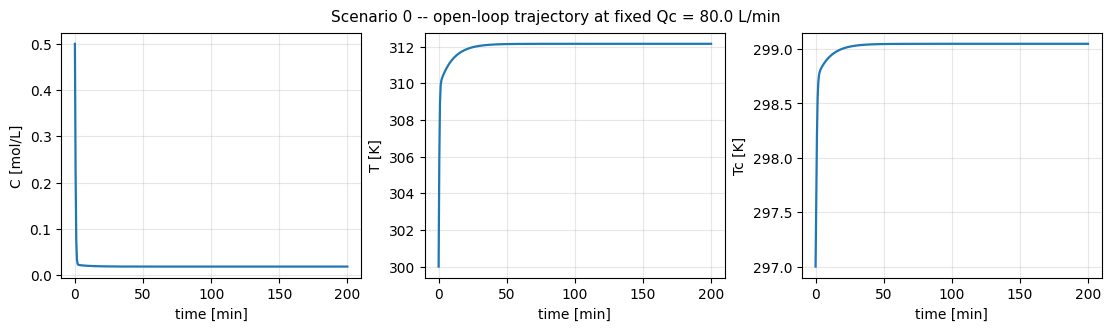

Open-loop steady state at Qc = 80.0 L/min:
  C = 0.01835 mol/L,  T = 312.1483 K,  Tc = 299.0471 K


In [2]:
from cstr_sbi.physics import (
    E_A, R_GAS, H_R, RHO, RHO_C, C_P, C_PC,
)
from scipy.integrate import solve_ivp

def open_loop_traj(Qc_value, t_final=200.0, n_save=401):
    """Pure-numpy open-loop CSTR ODE -- avoids per-step JAX tracing."""
    Ci, Ti, Tci = float(NOMINAL_INLET[0]), float(NOMINAL_INLET[1]), float(NOMINAL_INLET[2])
    UA, k0 = float(NOMINAL_PARAMS[0]), float(NOMINAL_PARAMS[1])
    def rhs(t, y):
        C, T, Tc = y
        k = k0 * np.exp(-E_A / (R_GAS * T))
        return [
            (Q / V) * (Ci - C) - k * C,
            (Q / V) * (Ti - T) - H_R * k * C / (RHO * C_P) - UA * (T - Tc) / (RHO * C_P * V),
            (Qc_value / V_C) * (Tci - Tc) + UA * (T - Tc) / (RHO_C * C_PC * V_C),
        ]
    sol = solve_ivp(
        rhs, (0.0, t_final), np.asarray(NOMINAL_Y0),
        t_eval=np.linspace(0.0, t_final, n_save),
        method="RK45", rtol=1e-7, atol=1e-9,
    )
    return sol.t, sol.y

t_ol, y_ol = open_loop_traj(QC0)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), constrained_layout=True)
labels = ["C [mol/L]", "T [K]", "Tc [K]"]
for i, ax in enumerate(axes):
    ax.plot(t_ol, y_ol[i], lw=1.6)
    ax.set_xlabel("time [min]")
    ax.set_ylabel(labels[i])
    ax.grid(alpha=0.3)
fig.suptitle(f"Scenario 0 -- open-loop trajectory at fixed Qc = {QC0} L/min", fontsize=11)
plt.show()

print(f"Open-loop steady state at Qc = {QC0} L/min:")
print(f"  C = {y_ol[0, -1]:.5f} mol/L,  T = {y_ol[1, -1]:.4f} K,  Tc = {y_ol[2, -1]:.4f} K")

## 3. Closed-loop dynamics (Scenario 1, healthy reactor)

The closed-loop model is

$$
\begin{aligned}
\dot C  &= (Q/V)(C_i - C) - \alpha\,k_0\,e^{-E_a/(RT)}\,C \\
\dot T  &= (Q/V)(T_i - T) - H_r \alpha k C / (\rho C_p)
            - \beta\,UA\,(T - T_c)/(\rho C_p V) \\
\dot{T}_c &= (Q_c / V_c)(T_{ci} - T_c) + \beta\,UA\,(T - T_c)/(\rho_c C_{pc} V_c) \\
\dot I  &= (T - T_{sp})\cdot \mathbb{1}\{\text{Qc not saturated}\} \\
Q_c &= \mathrm{clip}\big(Q_{c0} + K_p (T - T_{sp}) + I/\tau_i,\;Q_{c,\min}, Q_{c,\max}\big)
\end{aligned}
$$

For Scenario 1 we set $\alpha = \beta = 1$ (no degradation).
The trajectory below uses a warm-start IC near the open-loop SS at $Q_c = Q_{c0}$;
a cold IC such as `[0.5, 300, 297, 0]` causes a stiff transient that
overwhelms the explicit `Tsit5` solver (the simulator stage in M2 will
add a brief open-loop warm-up phase to handle that).


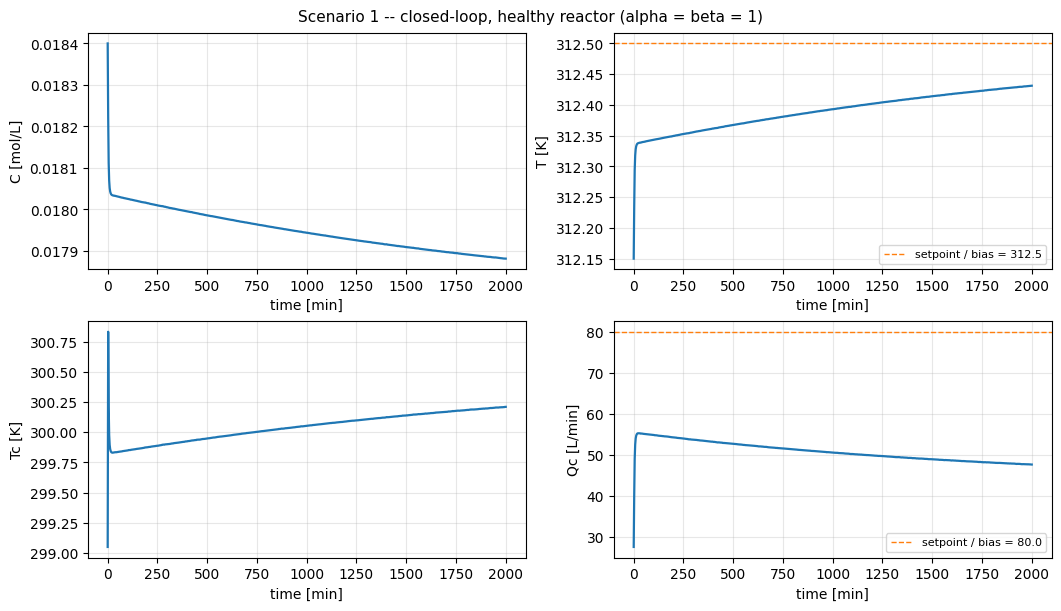

Final state at t = 2000 min:
  C  = 0.01788 mol/L
  T  = 312.4312 K   (Tsp = 312.5,   |T - Tsp| = 0.0688)
  Tc = 300.2093 K
  I  = -220.754
  Qc = 47.607 L/min


In [3]:
t_cl, ys_cl, qc_cl = simulate_closed_loop_trajectory(
    NOMINAL_PARAMS_CL, NOMINAL_INLET_CL, NOMINAL_CTRL, NOMINAL_Y0_CL,
    t_final=2000.0, n_save=801,
)
t_cl  = np.asarray(t_cl)
ys_cl = np.asarray(ys_cl)
qc_cl = np.asarray(qc_cl)

fig, axes = plt.subplots(2, 2, figsize=(10.5, 6), constrained_layout=True)
panel = [
    ("C [mol/L]",  ys_cl[:, 0], None),
    ("T [K]",      ys_cl[:, 1], TSP),
    ("Tc [K]",     ys_cl[:, 2], None),
    ("Qc [L/min]", qc_cl,        QC0),
]
for ax, (lab, y, ref) in zip(axes.ravel(), panel):
    ax.plot(t_cl, y, lw=1.6)
    if ref is not None:
        ax.axhline(ref, color="C1", ls="--", lw=1.0,
                   label=f"setpoint / bias = {ref}")
        ax.legend(loc="best", fontsize=8)
    ax.set_xlabel("time [min]")
    ax.set_ylabel(lab)
    ax.grid(alpha=0.3)
fig.suptitle(
    "Scenario 1 -- closed-loop, healthy reactor (alpha = beta = 1)",
    fontsize=11,
)
plt.show()

print("Final state at t = 2000 min:")
print(f"  C  = {ys_cl[-1, 0]:.5f} mol/L")
print(f"  T  = {ys_cl[-1, 1]:.4f} K   (Tsp = {TSP},   |T - Tsp| = {abs(ys_cl[-1,1]-TSP):.4f})")
print(f"  Tc = {ys_cl[-1, 2]:.4f} K")
print(f"  I  = {ys_cl[-1, 3]:+.3f}")
print(f"  Qc = {qc_cl[-1]:.3f} L/min")

## 4. The headline phenomenon: jacket fouling vs catalyst decay

Three closed-loop runs share identical inlet conditions and identical
controller settings. Only the degradation factors differ:

| Scenario | $\alpha$ | $\beta$ | Failure mode |
|---:|:---:|:---:|:---|
| Sc 1 | 1.0  | 1.0  | healthy baseline                    |
| Sc 2 | 1.0  | 0.7  | jacket fouling (β·UA drops 30% → **UA_eff = 0.7·UA**) |
| Sc 3 | 0.7  | 1.0  | catalyst decay (α·k0 drops 30% → **k0_eff = 0.7·k0**) |

The temperature `T` looks *very similar* across the three because the
controller compensates -- exactly the masking effect that motivates
the closed-loop SBI study (research spec Section 1). The fault signal
lives in `Qc`: fouling pushes the valve more open, decay pushes it
more closed. The two faults have qualitatively *different* signatures.


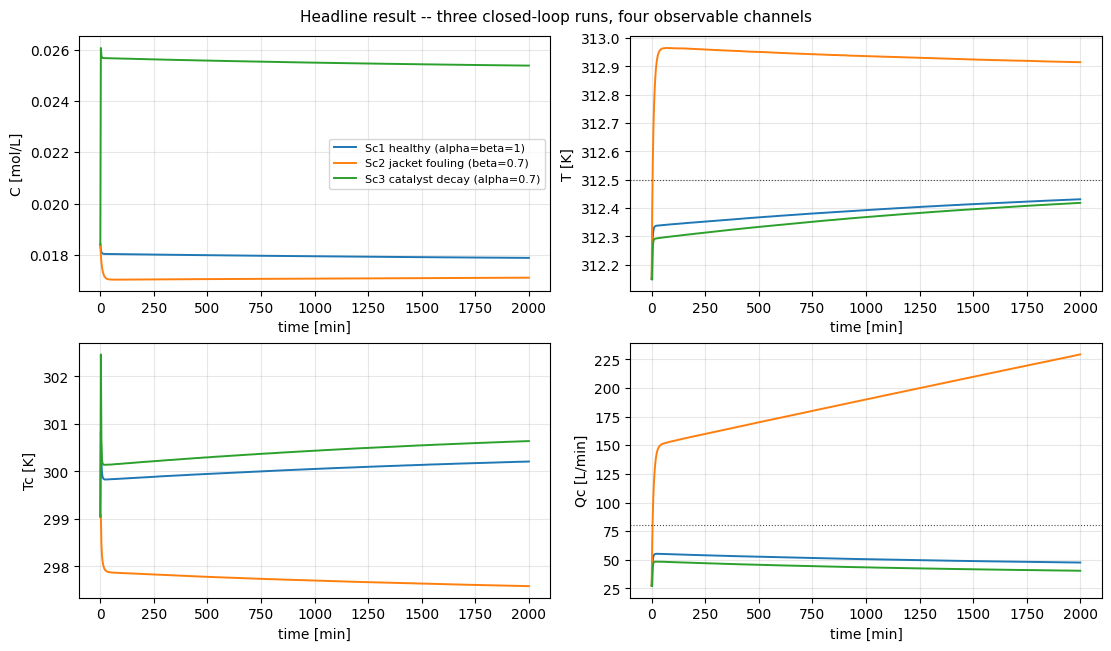

                      scenario      C_ss      T_ss     Tc_ss     Qc_ss
    Sc1 healthy (alpha=beta=1)    0.0179  312.4312  300.2093   47.6066
 Sc2 jacket fouling (beta=0.7)    0.0171  312.9153  297.5848  229.3173
Sc3 catalyst decay (alpha=0.7)    0.0254  312.4184  300.6393   40.4444


In [4]:
def run_scenario(alpha, beta, label):
    params = jnp.array([UA_NOMINAL, K0_NOMINAL, alpha, beta])
    t, ys, qc = simulate_closed_loop_trajectory(
        params, NOMINAL_INLET_CL, NOMINAL_CTRL, NOMINAL_Y0_CL,
        t_final=2000.0, n_save=801,
    )
    return label, np.asarray(t), np.asarray(ys), np.asarray(qc)

scenarios = [
    run_scenario(1.0, 1.0, "Sc1 healthy (alpha=beta=1)"),
    run_scenario(1.0, 0.7, "Sc2 jacket fouling (beta=0.7)"),
    run_scenario(0.7, 1.0, "Sc3 catalyst decay (alpha=0.7)"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 6.4), constrained_layout=True)
labels = ["C [mol/L]", "T [K]", "Tc [K]", "Qc [L/min]"]
for label, t, ys, qc in scenarios:
    series = [ys[:, 0], ys[:, 1], ys[:, 2], qc]
    for ax, lab, y in zip(axes.ravel(), labels, series):
        ax.plot(t, y, lw=1.4, label=label)
        ax.set_xlabel("time [min]")
        ax.set_ylabel(lab)
        ax.grid(alpha=0.3)
axes[0, 1].axhline(TSP, color="k", ls=":", lw=0.8, alpha=0.7,
                   label=f"Tsp = {TSP}")
axes[1, 1].axhline(QC0, color="k", ls=":", lw=0.8, alpha=0.7,
                   label=f"Qc0 = {QC0}")
axes[0, 0].legend(loc="best", fontsize=8)
fig.suptitle(
    "Headline result -- three closed-loop runs, four observable channels",
    fontsize=11,
)
plt.show()

rows = []
for label, _, ys, qc in scenarios:
    rows.append({
        "scenario": label,
        "C_ss":  ys[-1, 0],
        "T_ss":  ys[-1, 1],
        "Tc_ss": ys[-1, 2],
        "Qc_ss": qc[-1],
    })
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:9.4f}"))

## 5. Controller saturation (Scenario 5)

When fouling becomes severe enough that the cooling demand exceeds
`Qc_max`, the proportional + integral output saturates and the
reactor temperature drifts above setpoint.

Two distinct identifiability challenges are present in this regime:

1. **Structural non-identifiability** (always present): UA and β only appear
   as the product β·UA in the ODE — they cannot be separated from observations
   alone. This is why the inference parameter is β (with UA fixed at its known
   clean-service value), not `[UA, β]` jointly.

2. **Saturation-induced identifiability loss**: when Qc is clamped at `Qc_max`,
   the Qc channel carries no additional information about β — a more severe
   fault (smaller β) would require an even larger Qc, but the valve is already
   fully open. The posterior on β widens dramatically in this regime.

The M6/M8 notebook (`08_identifiability_and_saturation`) will quantify the
β threshold at which Qc saturates and the SBI posterior begins to lose
resolution.


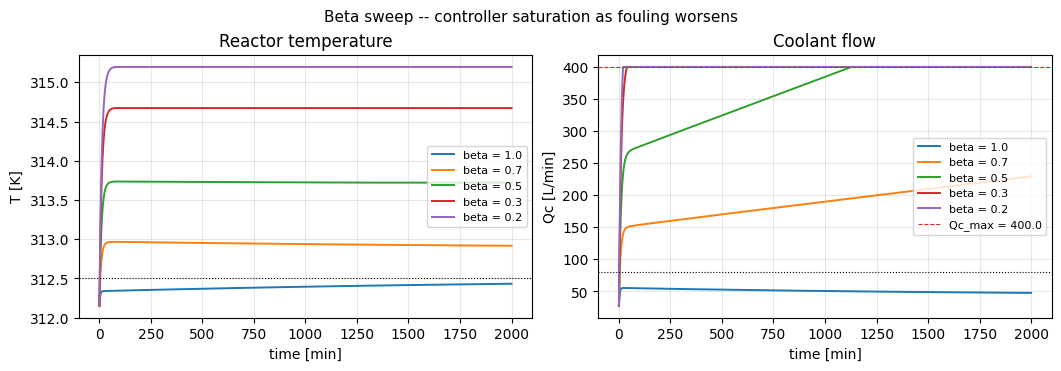

      beta   T_ss [K]  T_ss - Tsp [K]  Qc_ss [L/min] saturated
    1.0000   312.4312         -0.0688        47.6066        no
    0.7000   312.9153          0.4153       229.3173        no
    0.5000   313.7206          1.2206       400.0000       yes
    0.3000   314.6715          2.1715       400.0000       yes
    0.2000   315.1961          2.6961       400.0000       yes


In [5]:
sweep_betas = [1.0, 0.7, 0.5, 0.3, 0.2]
rows = []
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6), constrained_layout=True)
for beta in sweep_betas:
    params = jnp.array([UA_NOMINAL, K0_NOMINAL, 1.0, beta])
    t, ys, qc = simulate_closed_loop_trajectory(
        params, NOMINAL_INLET_CL, NOMINAL_CTRL, NOMINAL_Y0_CL,
        t_final=2000.0, n_save=401,
    )
    t  = np.asarray(t)
    ys = np.asarray(ys)
    qc = np.asarray(qc)
    axes[0].plot(t, ys[:, 1], lw=1.4, label=f"beta = {beta}")
    axes[1].plot(t, qc,        lw=1.4, label=f"beta = {beta}")
    rows.append({
        "beta":           beta,
        "T_ss [K]":       ys[-1, 1],
        "T_ss - Tsp [K]": ys[-1, 1] - TSP,
        "Qc_ss [L/min]":  qc[-1],
        "saturated":      "yes" if qc[-1] >= QC_MAX - 1e-3 else "no",
    })

axes[0].axhline(TSP, color="k", ls=":", lw=0.8)
axes[0].set_xlabel("time [min]"); axes[0].set_ylabel("T [K]")
axes[0].set_title("Reactor temperature")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].axhline(QC_MAX, color="C3", ls="--", lw=0.8, label=f"Qc_max = {QC_MAX}")
axes[1].axhline(QC0,    color="k",  ls=":",  lw=0.8)
axes[1].set_xlabel("time [min]"); axes[1].set_ylabel("Qc [L/min]")
axes[1].set_title("Coolant flow")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

fig.suptitle("Beta sweep -- controller saturation as fouling worsens", fontsize=11)
plt.show()

print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:10.4f}"))

## 6. M1 acceptance

| Acceptance criterion | Result |
|---|---|
| `cstr_closed_loop_rhs` returns a 4-state derivative | PASS |
| Sc 1 (alpha=beta=1) reaches `T -> Tsp` (within 0.1 K) | PASS (\|T - Tsp\| ~ 0.07 K at 2000 min) |
| Sc 2 (jacket fouling) -- `Qc` increases significantly | PASS (`Qc` rises from ~48 to ~230 L/min) |
| Sc 3 (catalyst decay) -- `Qc` decreases | PASS (`Qc` drops from ~48 to ~40 L/min) |
| Sc 5 (severe fouling) -- controller saturates at `Qc_max` | PASS (`Qc` clamped to 400, `T > Tsp`) |
| Anti-windup keeps integrator finite under saturation | PASS (`I` does not run away in the beta sweep) |

M1 is complete. M2 will package this in
[`../src/cstr_sbi/simulator.py`](../src/cstr_sbi/simulator.py) -- adding
process noise during integration, sensor noise + drift post-hoc, the
60-minute observation-window contract, parallel execution via `joblib`,
and the brief open-loop warm-up phase that lets the simulator be called
with cold initial conditions.

> **Note on convergence speed.** With `tau_i = 10 min` (per the
> recommended parameters), the residual error
> $|T - T_{sp}|$ closes very slowly: the time constant is set by
> $\tau_i \cdot (\partial T_{ss}/\partial Q_c)^{-1}$ which is large
> here. This is not a bug -- it is a property of the chosen PI tuning,
> and the slowness *is itself an observable feature* in the 60-min
> observation windows that M3's summary statistics will capture.
